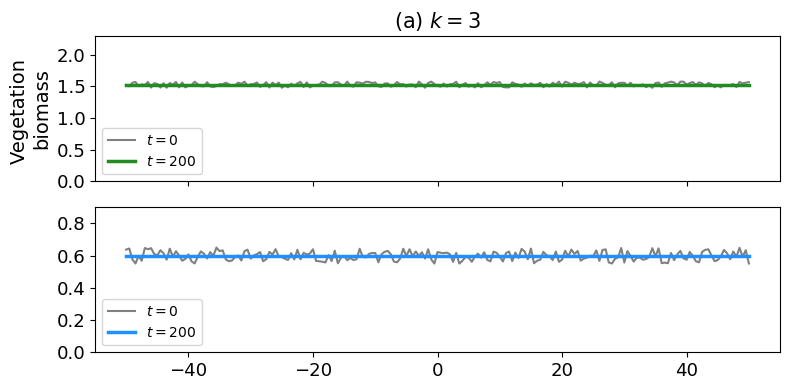

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator

#Parameters
A  = 2.0      
B  = 0.45     
K  = 3.0       #carrying capacity (logistic factor)
nu = 182.5   
d = 500.0     

T  = 200.0
dt = 0.01


#Large periodic domain + inner perturbation window
dx = 0.5
L_big = 800.0
L_in  = 200.0

N = int(L_big/dx)
x = np.linspace(0.0, L_big, N, endpoint=False)
x0 = L_big/2
inner_mask = np.abs(x - x0) <= L_in/2

#Wavenumbers for FFT (periodic)
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

#IMEX denominators (implicit linear part)
den_u = 1.0 + dt*(k**2)
den_w = 1.0 + dt*d*(k**2) - 1j*dt*nu*k


#equilibrium 
disc = A**2 - 4*B*(A/K + B)
if disc <= 0:
    raise ValueError("Need A^2 > 4 B (A/K + B) for vegetated equilibrium.")

u_ss = (A + np.sqrt(disc)) / (2*(A/K + B))
w_ss = A / (1 + u_ss**2)

#Initial condition
rng = np.random.default_rng(0)
eps_u, eps_w = 0.1, 0.1

u = np.full(N, u_ss)
w = np.full(N, w_ss)

u[inner_mask] += eps_u*(rng.random(inner_mask.sum()) - 0.5)
w[inner_mask] += eps_w*(rng.random(inner_mask.sum()) - 0.5)

u = np.maximum(u, 0.0)
w = np.maximum(w, 0.0)

u0 = u.copy()
w0 = w.copy()


#Time integration: IMEX Euler
#   implicit: diffusion (+ advection for w)
#   explicit: reactions
nsteps = int(round(T/dt))
for _ in range(nsteps):

    growth = w*u*u*(1.0 - u/K)

    uptake = w*u*u

    #reactions
    Ru = growth - B*u
    Rw = A - w - uptake

    u_hat = np.fft.fft(u)
    w_hat = np.fft.fft(w)

    u = np.fft.ifft((u_hat + dt*np.fft.fft(Ru)) / den_u).real
    w = np.fft.ifft((w_hat + dt*np.fft.fft(Rw)) / den_w).real

    #nonnegativity
    u = np.maximum(u, 0.0)
    w = np.maximum(w, 0.0)

#Plot 
x_rel = x - x0
plot_halfwidth = 50.0
plot_mask = np.abs(x_rel) <= plot_halfwidth

fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax[0].set_title(r"(a) $k=3$", fontsize=15)
ax[0].plot(x_rel[plot_mask], u0[plot_mask], lw=1.5, color="gray", label="$t=0$")
ax[0].plot(x_rel[plot_mask], u[plot_mask], lw=2.5, color="forestgreen", label=f"$t={int(T)}$")
ax[0].set_ylim(0, u_ss * 1.5)
ax[0].set_ylabel("Vegetation \nbiomass", fontsize=14)
ax[0].legend()

ax[1].plot(x_rel[plot_mask], w0[plot_mask], lw=1.5, color="gray", label="$t=0$")
ax[1].plot(x_rel[plot_mask], w[plot_mask], lw=2.5, color="dodgerblue", label=f"$t={int(T)}$")
ax[1].set_ylim(0, w_ss * 1.5)
ax[1].legend()

for axt in ax:
    axt.xaxis.set_major_locator(MultipleLocator(20))
    axt.yaxis.set_major_locator(MaxNLocator(nbins=5))
    axt.tick_params(axis='both', which='major', labelsize=13)
    
plt.tight_layout()
plt.savefig("Numeric Simulation Logistic 5.pdf")
plt.show()



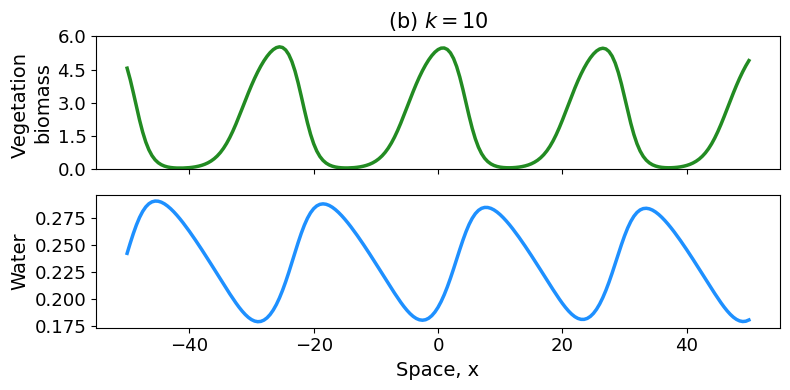

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator

#Parameters
A  = 2.0      
B  = 0.45     
K  = 10.0       #carrying capacity (logistic factor)
nu = 182.5   
d = 500.0        

T  = 200.0
dt = 0.01


#Large periodic domain + inner perturbation window
dx = 0.5
L_big = 800.0
L_in  = 200.0

N = int(L_big/dx)
x = np.linspace(0.0, L_big, N, endpoint=False)
x0 = L_big/2
inner_mask = np.abs(x - x0) <= L_in/2

#Wavenumbers for FFT (periodic)
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

#IMEX denominators (implicit linear part)
den_u = 1.0 + dt*(k**2)
den_w = 1.0 + dt*d*(k**2) - 1j*dt*nu*k

#equilibrium 
disc = A**2 - 4*B*(A/K + B)
if disc <= 0:
    raise ValueError("Need A^2 > 4 B (A/K + B) for vegetated equilibrium.")

u_ss = (A + np.sqrt(disc)) / (2*(A/K + B))
w_ss = A / (1 + u_ss**2)

#Initial condition
rng = np.random.default_rng(0)
eps_u, eps_w = 0.1, 0.1

u = np.full(N, u_ss)
w = np.full(N, w_ss)

u[inner_mask] += eps_u*(rng.random(inner_mask.sum()) - 0.5)
w[inner_mask] += eps_w*(rng.random(inner_mask.sum()) - 0.5)

u = np.maximum(u, 0.0)
w = np.maximum(w, 0.0)

u0 = u.copy()
w0 = w.copy()

#Time integration: IMEX Euler
#   implicit: diffusion (+ advection for w)
#   explicit: reactions
nsteps = int(round(T/dt))
for _ in range(nsteps):

    growth = w*u*u*(1.0 - u/K)
    uptake = w*u*u

    #reactions
    Ru = growth - B*u
    Rw = A - w - uptake

    u_hat = np.fft.fft(u)
    w_hat = np.fft.fft(w)

    u = np.fft.ifft((u_hat + dt*np.fft.fft(Ru)) / den_u).real
    w = np.fft.ifft((w_hat + dt*np.fft.fft(Rw)) / den_w).real

    #nonnegativity
    u = np.maximum(u, 0.0)
    w = np.maximum(w, 0.0)

#Plot 
x_rel = x - x0
plot_halfwidth = 50.0
plot_mask = np.abs(x_rel) <= plot_halfwidth

fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax[0].set_title(r"(b) $k=10$", fontsize=15)
ax[0].set_ylabel("Vegetation \nbiomass", fontsize=14)
ax[0].plot(x_rel[plot_mask], u[plot_mask], lw=2.5, color="forestgreen", label=f"$t={int(T)}$")
ax[0].set_ylim(0, 6)

ax[1].plot(x_rel[plot_mask], w[plot_mask], lw=2.5, color="dodgerblue", label=f"$t={int(T)}$")
ax[1].set_xlabel("Space, x", fontsize=14)
ax[1].set_ylabel("Water", fontsize=14)

for axt in ax:
    axt.xaxis.set_major_locator(MultipleLocator(20))
    axt.yaxis.set_major_locator(MaxNLocator(nbins=5))
    axt.tick_params(axis='both', which='major', labelsize=13)
    
plt.tight_layout()
plt.savefig("Numeric Simulation Logistic 10.pdf")
plt.show()

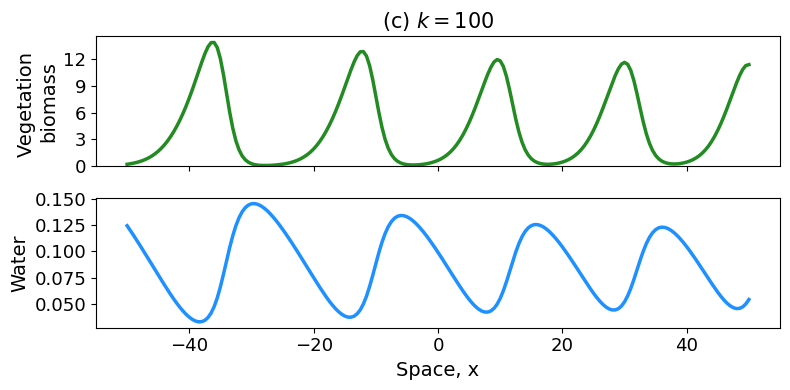

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator

#Parameters
A  = 2.0      
B  = 0.45      
K  = 1000.0       #carrying capacity (logistic factor)
nu = 182.5   
d = 500.0     

T  = 200.0
dt = 0.01


#Large periodic domain + inner perturbation window
dx = 0.5
L_big = 800.0
L_in  = 200.0

N = int(L_big/dx)
x = np.linspace(0.0, L_big, N, endpoint=False)
x0 = L_big/2
inner_mask = np.abs(x - x0) <= L_in/2

#Wavenumbers for FFT (periodic)
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

#IMEX denominators (implicit linear part)
den_u = 1.0 + dt*(k**2)
den_w = 1.0 + dt*d*(k**2) - 1j*dt*nu*k

#equilibrium 
disc = A**2 - 4*B*(A/K + B)
if disc <= 0:
    raise ValueError("Need A^2 > 4 B (A/K + B) for vegetated equilibrium.")

u_ss = (A + np.sqrt(disc)) / (2*(A/K + B))
w_ss = A / (1 + u_ss**2)

#Initial condition
rng = np.random.default_rng(0)
eps_u, eps_w = 0.1, 0.1

u = np.full(N, u_ss)
w = np.full(N, w_ss)

u[inner_mask] += eps_u*(rng.random(inner_mask.sum()) - 0.5)
w[inner_mask] += eps_w*(rng.random(inner_mask.sum()) - 0.5)

u = np.maximum(u, 0.0)
w = np.maximum(w, 0.0)

u0 = u.copy()
w0 = w.copy()

#Time integration: IMEX Euler
#   implicit: diffusion (+ advection for w)
#   explicit: reactions
nsteps = int(round(T/dt))
for _ in range(nsteps):

    growth = w*u*u*(1.0 - u/K)

    uptake = w*u*u

    #reactions
    Ru = growth - B*u
    Rw = A - w - uptake

    u_hat = np.fft.fft(u)
    w_hat = np.fft.fft(w)

    u = np.fft.ifft((u_hat + dt*np.fft.fft(Ru)) / den_u).real
    w = np.fft.ifft((w_hat + dt*np.fft.fft(Rw)) / den_w).real

    #nonnegativity
    u = np.maximum(u, 0.0)
    w = np.maximum(w, 0.0)

#Plot 
x_rel = x - x0
plot_halfwidth = 50.0
plot_mask = np.abs(x_rel) <= plot_halfwidth

fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

ax[0].plot(x_rel[plot_mask], u[plot_mask],  lw=2.5, color = "forestgreen")
ax[0].set_ylabel("Vegetation \nbiomass", fontsize=14)
ax[0].set_ylim(0, 14.5)


ax[0].set_title(r"(c) $k=100$", fontsize=15)
ax[1].plot(x_rel[plot_mask], w[plot_mask],  lw=2.5, color = "dodgerblue")
ax[1].set_xlabel("Space, x", fontsize=14)
ax[1].set_ylabel("Water", fontsize=14)

for axt in ax:
    axt.xaxis.set_major_locator(MultipleLocator(20))
    axt.yaxis.set_major_locator(MaxNLocator(nbins=5))
    axt.tick_params(axis='both', which='major', labelsize=13)
    
plt.tight_layout()
plt.savefig("Numeric Simulation Logistic 100.pdf")
plt.show()
